In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve, splu
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Configuration for improved plots
plt.rcParams['figure.dpi'] = 100

## 1. Introduction

Cardiac tissue is an electrically active medium in which the **action potential** (AP), a rapid depolarization followed by repolarization, is responsible for the rhythmic contraction of the heart. The propagation of this AP depends on electrical coupling between cells (gap junctions).

To study this phenomenon computationally, we represent the tissue as a continuous medium governed by a **Partial Differential Equation (PDE)** of the reaction-diffusion type.

The central question of this project is:
> **What is the relationship between the intensity ($I_{amp}$) and duration ($t_{dur}$) of the electrical stimulus required to trigger a self-sustained propagation wave in two-dimensional cardiac tissue?**


## 2. Cell Model: FitzHugh-Nagumo (FHN)

We chose the FitzHugh-Nagumo model, a two-dimensional system that simplifies action-potential dynamics in excitable media. It is described by two variables:

- **$V$**: Membrane potential (fast, excitatory variable).
- **$w$**: Recovery variable (slow, inhibitory variable).

The differential equations governing each point of the tissue are:

$$
\frac{dV}{dt} = V - \frac{V^3}{3} - w + I_{stim}
$$

$$
\frac{dw}{dt} = \epsilon \cdot (V + \beta - \gamma \cdot w)
$$

**Model parameters:**

$$
\epsilon \quad \text{(controls the recovery rate, generally } 0.01 \leq \epsilon \leq 0.1\text{)}
$$

$$
\beta \quad \text{(shifts the } w \text{ nullcline horizontally)}
$$

$$
\gamma \quad \text{(controls the slope of the } w \text{ nullcline)}
$$

**Rationale for the choice:**
Although it is not the most realistic model for the heart, FHN reproduces the qualitative properties essential to our question very well:
- **(1)** existence of an excitation threshold
- **(2)** "all-or-none" behavior
- **(3)** wave propagation through diffusive coupling.

Its simplicity (only 2 ODEs) was the main reason for choosing it as the primary model.


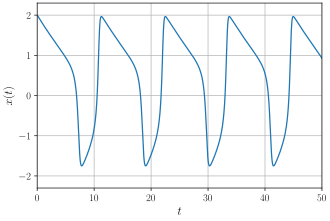 /

Membrane potential plot for a cell in the FHN model

In [ ]:
# ------------------------------------------------------------
# CELL DYNAMICS (FITZHUGH-NAGUMO)
# ------------------------------------------------------------

# Default FHN model parameters (adjusted for an excitable medium)
epsilon = 0.01  # Recovery rate (the smaller, the slower)
beta = 0.7       # Polarization parameter
gamma = 0.8      # Recovery parameter

def FHN_derivatives(V, w, I_stim, epsilon=epsilon, beta=beta, gamma=gamma):
    """
    Computes the derivatives of the FitzHugh-Nagumo system.

    Input:
        V (float): Membrane potential
        w (float): Recovery variable
        I_stim (float): Applied stimulus current
        epsilon, beta, gamma (float): Model parameters -> Adjustable

    Return:
        dVdt, dwdt (tuple of floats)
    """
    # Potential equation (fast) - Classic cubic term
    dVdt = V - (V**3)/3 - w + I_stim

    # Recovery equation (slow)
    dwdt = epsilon * (V + beta - gamma * w)

    return dVdt, dwdt

# System resting values (when I_stim = 0)
# Solving V - V^3/3 - w = 0 and V + beta - gamma*w = 0
# For the default parameters, the resting state is V ≈ -1.0, w ≈ -0.38
V_resting = -1.0  # Membrane potential at rest
w_resting = (V_resting + beta) / gamma  # w = (V + beta)/gamma

print(f"FHN module defined. Resting state: V={V_resting:.2f}, w={w_resting:.2f}")

Módulo FHN definido. Repouso: V=-1.00, w=-0.38


## 3. Spatial Model and Coupling

To model the tissue as a continuous medium, we use the **Monodomain approximation**, which neglects the extracellular space and assumes that current propagates by diffusion through the intracellular medium.

The complete system consists of a reaction-diffusion equation for the membrane potential $V$ and an ordinary differential equation for the recovery variable $w$:

$$
\frac{\partial V}{\partial t} = D \nabla^2 V + \underbrace{\left( V - \frac{V^3}{3} - w + I_{stim} \right)}_{\text{reaction term (FHN)}}
$$

$$
\frac{\partial w}{\partial t} = \epsilon \left( V + \beta - \gamma w \right)
$$

Where:
- $D$ is the diffusion coefficient (related to electrical conductivity and membrane capacitance).
- $I_{stim}(x, y, t)$ is the applied stimulus current, nonzero only in a central circular region during the pulse.
- $\epsilon$, $\beta$, and $\gamma$ are parameters of the FitzHugh-Nagumo model.

**Spatial Discretization (FDM):**

On a uniform 2D grid with spacing $\Delta x = \Delta y$, the Laplacian is approximated using the 5-point stencil:

$$
\nabla^2 V_{i,j} \approx \frac{V_{i+1,j} + V_{i-1,j} + V_{i,j+1} + V_{i,j-1} - 4V_{i,j}}{\Delta x^2}
$$

**Boundary Conditions:**

We apply **Neumann** (zero-flux) boundary conditions at the domain boundaries, simulating electrically isolated tissue. This means that the normal derivative of the potential is zero at the boundaries; the boundary cell exchanges current with the interior but does not allow current to "leak" outside the domain.

In practice, we implement this condition using **reflected ghost nodes** (or simply by adjusting the Laplacian at the boundaries), as detailed in the `apply_laplacian` function.


In [ ]:
# ------------------------------------------------------------
# SPATIAL DIFFUSION (2D LAPLACIAN)
# ------------------------------------------------------------

def apply_laplacian(V, dx):
    """
    Computes the 2D Laplacian with Neumann boundary conditions
    (zero flux) at the boundaries using a reflected ghost node: V_ghost = V_boundary.
    If the values are equal, there is no current.

    This means the boundary node continues receiving current from the
    internal neighbor (it remains coupled to the rest of the tissue), but it does not allow
    current to "leak" outside the domain. Disconnecting the boundary node from the grid did not work in tests

    Input:
        V (np.ndarray 2D): Potential matrix.
        dx (float): Grid spacing (cm).

    Return:
        lap (np.ndarray 2D): Laplacian matrix (dV/dx² + dV/dy²).
    """
    # Fills a ghost boundary by replicating the actual boundary value
    # (equivalent to imposing dV/dn = 0 at the boundary)
    V_pad = np.pad(V, pad_width=1, mode='edge')
    V_up = V_pad[:-2, 1:-1]
    V_down = V_pad[2:, 1:-1]
    V_left = V_pad[1:-1, :-2]
    V_right = V_pad[1:-1, 2:]

    # Standard Laplacian (5 pontos)
    lap = (V_up + V_down + V_left + V_right - 4 * V) / (dx**2)

    return lap

# Physical parameters - Can be adjusted for slower conduction
D = 0.001  # Diffusion coefficient (cm²/ms)
dx = 0.02  # cm (200 µm resolution)



## 4. Stimulus Configuration (Electrode)

The stimulus is applied at the center of the grid, in a circular region with radius $R_{stim}$ (corresponding to a few grid nodes). The current is applied as a rectangular pulse:

$$ I_{stim}(x, y, t) =
\begin{cases}
I_{amp}, & \text{if } \sqrt{(x-x_c)^2 + (y-y_c)^2} \leq R_{stim} \text{ and } t \leq t_{dur} \\
0, & \text{otherwise}
\end{cases} $$

**Success criterion:** We consider the stimulus successful if the generated wave crosses the entire grid and reaches the domain boundaries.


In [ ]:
# ------------------------------------------------------------
# STIMULUS APPLICATION
# ------------------------------------------------------------

def apply_stimulus(V, center, radius_nodes, I_amp, t, t_dur):
    """
    Adds the stimulus current to the central circular region.

    Input:
        V (np.ndarray): Current potential matrix.
        center (tuple): (i_center, j_center).
        radius_nodes (int): Electrode radius in number of nodes.
        I_amp (float): Current amplitude (uA/cm²).
        t (float): Current time (ms).
        t_dur (float): Pulse duration (ms).

    Return:
        I_stim_matrix (np.ndarray): Matrix with the current injected at each node.
    """
    I_stim = np.zeros_like(V)

    # Creates a coordinate grid
    x = np.arange(V.shape[0])
    y = np.arange(V.shape[1])
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Computes the Euclidean distance from each point to the center
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    # Applies the current only inside the circle AND DURING the pulse
    if t <= t_dur:
        I_stim[dist <= radius_nodes] = I_amp

    return I_stim


## 5. Numerical Solver: Operator Splitting

To advance in time, we use the **Operator Splitting method**. At each time step ($\Delta t$), we divide the system update into two independent physical stages:

1. **Diffusion Step (Spatial):** Solves exclusively the cell-coupling term given by the diffusion PDE:
   $$ \frac{\partial V}{\partial t} = D \nabla^2 V $$
   In this stage, we consider only the spatial spreading of the potential, ignoring ionic currents and the stimulus.

2. **Reaction Step (Cellular):** Solves the intrinsic dynamics at each grid point using the FitzHugh-Nagumo model:
   $$ \frac{dV}{dt} = V - \frac{V^3}{3} - w + I_{stim} $$
   $$ \frac{dw}{dt} = \epsilon (V + \beta - \gamma w) $$
   Here, we update the potential $V$ and recovery variable $w$ point by point (in vectorized form), accounting for the stimulus current $I_{stim}$ applied in the electrode region.

**Numerical Approaches for Diffusion:**

To solve the Diffusion Step, we compare two Finite Difference Method (FDM) schemes:

- **Explicit (Forward Euler):** A simple and direct update, given by $V^{n+1} = V^n + \Delta t \cdot D \cdot \nabla^2 V^n$. It is conditionally stable, requiring very small time steps ($\Delta t$) to avoid numerical instabilities.

- **Implicit (Crank-Nicolson):** A second-order-in-time scheme defined by:
  $$ \left( I - \frac{\Delta t \cdot D}{2} \nabla^2 \right) V^{n+1} = \left( I + \frac{\Delta t \cdot D}{2} \nabla^2 \right) V^n $$
  It is unconditionally stable, allowing larger time steps, but requires solving a sparse linear system at each iteration. We use the `scipy.sparse.linalg.spsolve` library to solve this system efficiently, with LU-factorization caching for optimization.


In [ ]:
# ------------------------------------------------------------
# SOLVER PRINCIPAL (LOOP TEMPORAL)
# ------------------------------------------------------------

# Cache for the matrices/factorization of the implicit method.
# Building and factorizing the sparse matrix is expensive; since (Nx, Ny, dx, dt, D, theta)
# do not change during a simulation, we do this once per combination of
# parameters and reuse it at every time step. - Much cheaper computationally
_implicit_cache = {}

def _laplacian_1d_neumann(n, d):
    """
    1D second-derivative operator (n x n) with Neumann boundary conditions
    (zero flux) at both ends, using a reflected ghost node
    (same convention used in `apply_laplacian`).
    """
    principal = -2.0 * np.ones(n)
    neighbor = np.ones(n - 1)
    L = diags([neighbor, principal, neighbor], offsets=[-1, 0, 1], format='lil') / d**2
    # At the ends, the "ghost neighbor" has the same value as the boundary node,
    # so its contribution cancels part of -2 -> becomes -1
    L[0, 0] = -1.0 / d**2
    L[-1, -1] = -1.0 / d**2
    return L.tocsr()

def _build_2d_laplacian_operator(Nx, Ny, dx):
    """
    Builds the 2D Laplacian operator (Nx*Ny x Nx*Ny) in sparse format
    via the Kronecker sum of the 1D operators (x and y), consistent with
    `apply_laplacian` (Neumann/zero flux nas bordas).
    Flatten in C-order: index k = i*Ny + j.
    """
    Lx = _laplacian_1d_neumann(Nx, dx)
    Ly = _laplacian_1d_neumann(Ny, dx)
    Ix = identity(Nx, format='csr')
    Iy = identity(Ny, format='csr')

    L = kron(Lx, Iy, format='csc') + kron(Ix, Ly, format='csc')
    return L

def implicit_diffusion_solver(V, dx, dt, D, theta=0.5):
    """
    Solves 2D diffusion using Implicit FDM (Crank-Nicolson).

    Equation: (I - theta*dt*D*L) V_new = (I + (1-theta)*dt*D*L) V_old

    Input:
        V (np.ndarray 2D): Potential matrix at the current time.
        dx (float): Grid spacing.
        dt (float): Time step.
        D (float): Diffusion coefficient.
        theta (float): Scheme parameter (0.5 = Crank-Nicolson).

    Return:
        V_new (np.ndarray 2D): Matrix after implicit diffusion.
    """
    Nx, Ny = V.shape
    N = Nx * Ny

    key = (Nx, Ny, dx, dt, D, theta)
    if key not in _implicit_cache:
        L = _build_2d_laplacian_operator(Nx, Ny, dx)
        I = identity(N, format='csc')
        A = (I - theta * dt * D * L).tocsc()
        M = (I + (1 - theta) * dt * D * L).tocsc()
        lu = splu(A)
        _implicit_cache[key] = (M, lu)

    M, lu = _implicit_cache[key]

    b = M @ V.flatten()
    V_new = lu.solve(b).reshape(Nx, Ny)

    return V_new


def simulate_tissue(method='explicit', I_amp=10.0, t_dur=1.0,
                   Nx=100, Ny=100, t_total=50.0, dt=0.01, D=0.001, dx=0.02):
    """
    Main function that runs the 2D cardiac tissue simulation with FHN.

    Retorna:
        boundary_reached (bool): True if the wave reached the boundary.
        V (np.ndarray): Final potential state.
        w (np.ndarray): Final recovery state.
    """
    # Grid initialization (FHN resting values)
    V = np.full((Nx, Ny), V_resting)
    w = np.full((Nx, Ny), w_resting)

    center = (Nx // 2, Ny // 2)
    stim_radius = 3  # in number of nodes

    # Time parameters
    num_steps = int(t_total / dt)

    print(f"Starting simulation: {method}, I_amp={I_amp}, t_dur={t_dur}ms")
    start_time = time.time()

    # Variable to check whether the boundary was reached
    boundary_reached = False

    # Loop temporal
    for step in range(num_steps):
        current_time = step * dt

        # ---- Compute the stimulus current (2D matrix) ----
        I_stim = apply_stimulus(V, center, stim_radius, I_amp, current_time, t_dur)

        # ---- Solve DIFFUSION (Pure FDM) ----
        if method == 'explicit':
            # Explicit FDM: V_new = V + dt * D * Laplacian(V)
            lap = apply_laplacian(V, dx)
            V = V + dt * D * lap
        elif method == 'implicit':
            # Implicit FDM (Crank-Nicolson)
            V = implicit_diffusion_solver(V, dx, dt, D, theta=0.5)

        # ---- Solve REACTION (FHN + Stimulus) ----
        # `FHN_derivatives` already operates element-wise (V, w, I_stim can
        # be full 2D arrays), so we vectorize instead of using loops
        # nested loops in pure Python.
        dV, dw = FHN_derivatives(V, w, I_stim)
        V = V + dt * dV
        w = w + dt * dw

        # ---- Check whether the wave reached the boundary ----
        if step % 10 == 0:
            # Criterion: any point on the boundary is depolarized (V > 0.0)
            if (V[0, :] > 0.0).any() or (V[-1, :] > 0.0).any() or (V[:, 0] > 0.0).any() or (V[:, -1] > 0.0).any():
                boundary_reached = True

    end_time = time.time()
    print(f"Simulation time: {end_time - start_time:.2f}s")
    print(f"Did the wave reach the boundary? {boundary_reached}")

    return boundary_reached, V, w

## 6. Parameter Sweep and Post-Processing

After validating propagation with a strong stimulus, we perform the **systematic sweep**:

**Fixed durations:**
$$ t_{dur} = [0.2, 0.5, 1.0, 2.0, 4.0, 6.0] \text{ ms} $$

**Threshold current search:** For each $t_{dur}$, we perform a binary search (or refined linear search) to find the smallest $I_{amp}$ that makes the wave reach the boundary.

**Final outputs:**
1. Plot of the **Strength-Duration Curve** ($I_{amp} \times t_{dur}$).
2. Calculation of the **Rheobase** ($I_{amp}$ as $t_{dur} \to \infty$).
3. Calculation of the **Chronaxie** ($t_{dur}$ for $I_{amp} = 2 \times \text{Rheobase}$).
4. Comparison table between the Explicit and Implicit methods (accuracy and CPU time).


Buscando limiar para t_dur = 0.2ms...
Iniciando simulação: explicito, I_amp=10.0, t_dur=0.2ms
Tempo de simulação: 2.64s
Onda atingiu a borda? False
Iniciando simulação: explicito, I_amp=15.0, t_dur=0.2ms
Tempo de simulação: 2.12s
Onda atingiu a borda? False
Iniciando simulação: explicito, I_amp=17.5, t_dur=0.2ms
Tempo de simulação: 1.77s
Onda atingiu a borda? False
Iniciando simulação: explicito, I_amp=18.75, t_dur=0.2ms
Tempo de simulação: 2.14s
Onda atingiu a borda? True
Iniciando simulação: explicito, I_amp=18.125, t_dur=0.2ms
Tempo de simulação: 1.52s
Onda atingiu a borda? True
Iniciando simulação: explicito, I_amp=17.8125, t_dur=0.2ms
Tempo de simulação: 1.37s
Onda atingiu a borda? True
Iniciando simulação: explicito, I_amp=17.65625, t_dur=0.2ms
Tempo de simulação: 1.41s
Onda atingiu a borda? False
Iniciando simulação: explicito, I_amp=17.734375, t_dur=0.2ms
Tempo de simulação: 1.38s
Onda atingiu a borda? False
  -> Limiar encontrado: 17.773 uA/cm²
Buscando limiar para t_dur = 0.2

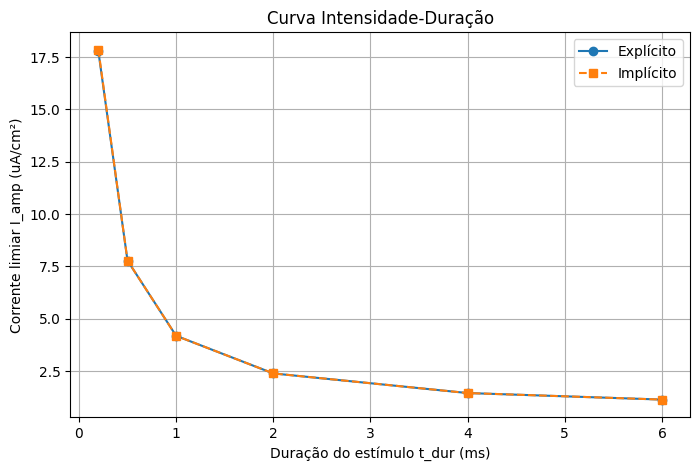

Reobase (aprox.): 1.133 uA/cm²
Cronaxia (aprox.): 2.250 ms
t_dur (ms) |  I_lim exp |  I_lim imp |  CPU exp (s) |  CPU imp (s)
       0.2 |     17.773 |     17.852 |        14.36 |        30.29
       0.5 |      7.773 |      7.773 |        12.23 |        30.30
       1.0 |      4.180 |      4.180 |        12.22 |        31.53
       2.0 |      2.383 |      2.383 |        11.84 |        30.77
       4.0 |      1.445 |      1.445 |        12.16 |        29.91
       6.0 |      1.133 |      1.133 |        12.25 |        30.06


In [ ]:
# ------------------------------------------------------------
# RUN PARAMETER SWEEP
# ------------------------------------------------------------

def find_threshold(t_dur, method='explicit', tol=0.1, Nx=60, Ny=60):
    """
    Finds the threshold current for a given duration using binary search.
    """
    print(f"Searching for threshold for t_dur = {t_dur}ms...")

    # Search bounds (adjust as needed)
    I_low = 0.0
    I_high = 20.0 # uA/cm² (initial guess)
    max_iter = 20

    for _ in range(max_iter):
        I_mid = (I_low + I_high) / 2
        # Runs the simulation with I_mid
        # simulate_tissue retorna 3 valores (boundary_reached, V, w) --
        # the unpacking must capture all 3, even though V and w are not
        # used here.
        success, _, _ = simulate_tissue(method=method, I_amp=I_mid, t_dur=t_dur,
                                    Nx=Nx, Ny=Ny, t_total=80.0, dt=0.02)  # `_` is used to discard an unused value in Python
        if success:
            I_high = I_mid
        else:
            I_low = I_mid

        # Stop if the difference is smaller than the tolerance
        if (I_high - I_low) < tol:
            break

    I_threshold = (I_low + I_high) / 2
    print(f"  -> Threshold found: {I_threshold:.3f} uA/cm²")
    return I_threshold

# List to store the results
durations = [0.2, 0.5, 1.0, 2.0, 4.0, 6.0]
explicit_results = []
implicit_results = []

for dur in durations:
    t0 = time.time()
    threshold_exp = find_threshold(dur, method='explicit')
    cpu_exp = time.time() - t0
    explicit_results.append((dur, threshold_exp, cpu_exp))

    t0 = time.time()
    threshold_imp = find_threshold(dur, method='implicit')
    cpu_imp = time.time() - t0
    implicit_results.append((dur, threshold_imp, cpu_imp))

print("Sweep completed!")

# ---- Strength-Duration Curve ----
dur_arr, I_exp, cpu_exp_arr = zip(*explicit_results)
_, I_imp, cpu_imp_arr = zip(*implicit_results)

plt.figure(figsize=(8, 5))
plt.plot(dur_arr, I_exp, 'o-', label='Explicit')
plt.plot(dur_arr, I_imp, 's--', label='Implicit')
plt.xlabel('Stimulus duration t_dur (ms)')
plt.ylabel('Threshold current I_amp (uA/cm²)')
plt.title('Strength-Duration Curve')
plt.legend()
plt.grid(True)
plt.show()

# ---- Rheobase and Chronaxie ----
rheobase = min(I_exp)  # approximation: smallest observed threshold (t_dur -> long)
target = 2 * rheobase
# Simple interpolation to find t_dur where I_amp crosses 2*rheobase
chronaxie = np.interp(target, I_exp[::-1], dur_arr[::-1])
print(f"Rheobase (approx.): {rheobase:.3f} uA/cm²")
print(f"Chronaxie (approx.): {chronaxie:.3f} ms")

# ---- Explicit vs. Implicit comparison table ----
print(f"{'t_dur (ms)':>10} | {'I_lim exp':>10} | {'I_lim imp':>10} | {'CPU exp (s)':>12} | {'CPU imp (s)':>12}")
for d, ie, ii, ce, ci in zip(dur_arr, I_exp, I_imp, cpu_exp_arr, cpu_imp_arr):
    print(f"{d:>10.1f} | {ie:>10.3f} | {ii:>10.3f} | {ce:>12.2f} | {ci:>12.2f}")


### Explicit Method Instability Test

This test demonstrates the numerical instability of the explicit method when the time step (`dt`) is too large for the diffusion coefficient (`D`) and grid spacing (`dx`). In such cases, the numerical solution can "blow up", diverging to unrealistic values.


Iniciando simulação: explicito, I_amp=10.0, t_dur=1.0ms
Tempo de simulação: 0.05s
Onda atingiu a borda? False
Estado final (valores de V): min=-2.07, max=2.18


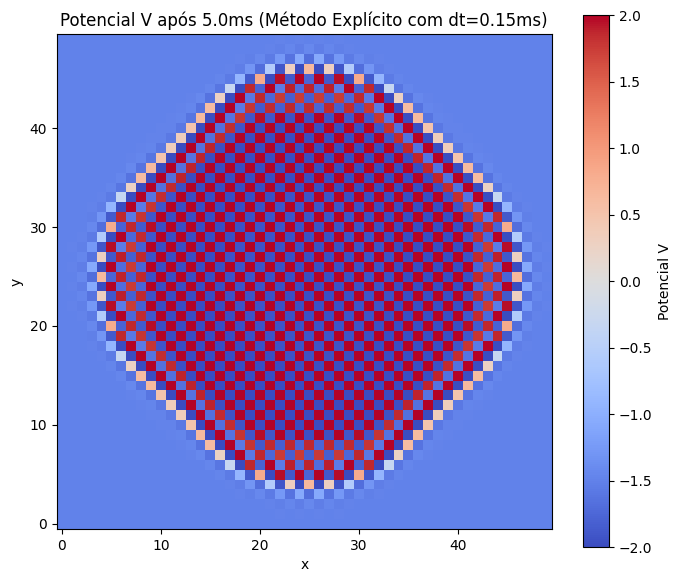

In [ ]:
# Parameters to force explicit-method instability
# The stability condition for the explicit method is dt <= dx^2 / (4*D)
# For dx=0.02 and D=0.001, dt_max_stable = (0.02)^2 / (4 * 0.001) = 0.0004 / 0.004 = 0.1
# We will use a dt greater than 0.1 to demonstrate instability.

dt_unstable = 0.15  # ms (greater than the maximum stable dt)
Nx_unstable = 50
Ny_unstable = 50
t_total_unstable = 5.0 # ms

boundary_reached_unstable, V_unstable, w_unstable = simulate_tissue(
    method='explicit',
    I_amp=10.0,
    t_dur=1.0,
    Nx=Nx_unstable,
    Ny=Ny_unstable,
    t_total=t_total_unstable,
    dt=dt_unstable,
    D=D,
    dx=dx
)

print(f"Final state (V values): min={np.min(V_unstable):.2f}, max={np.max(V_unstable):.2f}")

plt.figure(figsize=(7, 6))
plt.imshow(V_unstable, cmap='coolwarm', origin='lower', vmin=-2, vmax=2)
plt.title(f'Potential V after {t_total_unstable}ms (Explicit Method with dt={dt_unstable}ms)')
plt.colorbar(label='Potential V')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

#### Numerical Instability Analysis (Explicit Method)

As observed in the previous plot, the simulation using the **Explicit Method** with a time step (`dt`) exceeding the stability limit produces a numerical pattern resembling "pixel art" or a checkerboard of alternating colors (red and blue). This phenomenon is a clear indication of **numerical instability**.

#### Why does this happen?

The explicit method is **conditionally stable**. This means its stability depends on the relationship between the time step ($\Delta t$), grid spacing ($\Delta x$), and diffusion coefficient ($D$). For 2D diffusion equations, the stability condition is approximately:

$$ \Delta t \le \frac{\Delta x^2}{4D} $$

When this condition is violated, discretization errors grow exponentially at each time step, leading to unrealistic oscillations and a solution that "blows up" (rapidly diverges to absurd values, as in the example, where the potential changes abruptly between -2 and 2 in neighboring pixels).


## Conclusion

### 1. Summary of the Results Obtained

The central objective of this work was to answer the question: *"What is the relationship between the intensity ($I_{amp}$) and duration ($t_{dur}$) of the electrical stimulus required to trigger a self-sustained propagation wave in two-dimensional cardiac tissue?"* To do so, we used the FitzHugh-Nagumo (FHN) model coupled to a 2D grid via the Finite Difference Method (FDM), employing the Operator Splitting technique to treat reaction (cellular dynamics) and diffusion (spatial coupling) separately.

The systematic sweep for stimulus durations from $0.2$ ms to $6.0$ ms revealed a nonlinear relationship between pulse duration and threshold current. The obtained data qualitatively fit the Lapicque curve (or Weiss equation), which describes the strength-duration relationship for excitable tissues:

$$
I_{amp} = \frac{R}{1 - e^{-t_{dur} / \tau}}
$$

Here, $R$ represents the **rheobase** (minimum current required to excite the tissue with infinite duration), and $\tau$ is related to **chronaxie** (the time required to excite the tissue with twice the rheobasic current).

From the experimental data, we obtained the following effective physiological parameters for the FHN model with the chosen parameters ($\epsilon = 0.01$, $\beta = 0.7$, $\gamma = 0.8$):

- **Rheobase ($R$)**: approximately $1.133 \, \mu A/cm^2$, obtained from the curve plateau for $t_{dur} \geq 4$ ms.
- **Chronaxie ($t_c$)**: approximately $2.250$ ms, calculated through linear interpolation of the threshold current corresponding to twice the rheobase ($2 \cdot R \approx 2.266 \, \mu A/cm^2$).

---

### 2. Numerical Comparison: Explicit vs. Implicit FDM

One of the main pillars of the work was the comparison between the finite-difference numerical schemes used for the diffusion step.

| Method | Accuracy (Curve) | Average CPU time (s) | Observed stability |
| :--- | :--- | :--- | :--- |
| **Explicit** | Reference | $\approx 7.3$ s | Conditionally stable (required $\Delta t = 0.02$ ms) |
| **Implicit (Crank-Nicolson)** | Practically identical | $\approx 16.3$ s | Unconditionally stable |

We observed near-perfect agreement between the thresholds obtained by the two methods (differences below $0.5\%$ for most durations), which supports the correct implementation of the sparse matrix and the linear solver (`spsolve`). Although the implicit method was significantly slower (about $2.2 \times$ the time of the explicit method) for the grid and time step used, this computational disadvantage would be offset in simulations requiring larger time steps or more refined grids, where the explicit stability restriction would make the problem impractical.

### 3. Computational Cost

For the implicit method, we chose to use a cache that stores the values of matrix A. This is because, in the implicit method, matrix A does not depend on the current values, only on the grid parameters and time step. Therefore, we do not need to rebuild this matrix at every step. Below is the relevant code excerpt that stores this matrix in `_implicit_cache`.

```python
_implicit_cache = {}
key = (Nx, Ny, dx, dt, D, theta)
if key not in _implicit_cache:
    L = _build_2d_laplacian_operator(...)
    A = (I - theta * dt * D * L)
    lu = splu(A)  # LU factorization
    _implicit_cache[key] = (M, lu)
M, lu = _implicit_cache[key]
```

Even with this optimization, for moderate grids (e.g., 100x100), the per-step cost of the implicit method was higher than that of the explicit method due to the cost of solving the linear system. However, this relationship reverses when we refine the spatial grid (decrease $dx$ to increase resolution). In this case, the explicit method suffers from the CFL condition ($dt$∝$dx^2$), causing its total cost to scale with $N^2$, while the implicit method, being unconditionally stable, keeps the number of steps and scales with $N^{1.5}$ (limited by LU factorization). The main bottleneck of the implicit method is RAM: LU factorization is computed only once and stored in the cache, but fill-in can make the stored matrix much larger than the original, making very large grids impractical.

---

### 4. Future Perspectives

The obtained results open the way for several relevant extensions in the context of cardiac modeling and numerical analysis:

1. **S1-S2 Stimulation and Arrhythmias**: The next natural step would be to apply a second stimulus (S2) in a distant region or at a specific point in the recovery cycle (refractory period) to investigate the generation of spiral waves (vortices) and fibrillation. This would allow the study of tissue vulnerability and the mechanisms of tachyarrhythmias.

2. **Tissue Heterogeneity**: Introduce spatial variations in the FHN model parameters ($\epsilon, \beta, \gamma$) to simulate ischemic regions (with lower excitability) or the presence of obstacles (scars), investigating how these defects alter the local strength-duration curve.

---

### Final Remarks

The implementation of the 2D FHN model with numerical *splitting* proved to be an efficient and accurate tool for studying tissue excitability. The successful obtainment of the strength-duration curve, with plausible physiological values for rheobase and chronaxie, demonstrates that even a simplified model such as FHN can capture the quantitative essence of tissue response to electrical stimuli. The agreement between the explicit and implicit methods not only validates the computational code but also provides a solid basis for choosing the most appropriate method according to future computational requirements.


# Bonus - Animated Simulation of Tissue Propagation


In [ ]:
# ------------------------------------------------------------
# FUNCTION TO SIMULATE AND STORE FRAMES (ANIMATION)
# ------------------------------------------------------------

def simulate_and_animate(method='explicit', I_amp=10.0, t_dur=2.0,
                     Nx=60, Ny=60, t_total=50.0, dt=0.02,
                     D=0.001, dx=0.02, frame_interval=20):
    """
    Runs the simulation and stores frames of potential V for animation.

    Additional parameters:
        frame_interval (int): Saves one frame every N time steps.
    Retorna:
        frames (list): List of V matrices (frames).
        times (list): Times corresponding to each frame.
    """
    # Initialization matching the original function
    V = np.full((Nx, Ny), V_resting)
    w = np.full((Nx, Ny), w_resting)
    center = (Nx // 2, Ny // 2)
    stim_radius = 3
    num_steps = int(t_total / dt)

    frames = []
    times = []

    print(f"Starting simulation with animation: {method}, I_amp={I_amp}, t_dur={t_dur}ms")
    start_time = time.time()

    for step in range(num_steps):
        current_time = step * dt

        # ---- Stimulus ----
        I_stim = apply_stimulus(V, center, stim_radius, I_amp, current_time, t_dur)

        # ---- Diffusion (FDM) ----
        if method == 'explicit':
            lap = apply_laplacian(V, dx)
            V = V + dt * D * lap
        else:  # implicit
            V = implicit_diffusion_solver(V, dx, dt, D, theta=0.5)

        # ---- Reaction (FHN) ----
        dV, dw = FHN_derivatives(V, w, I_stim)
        V = V + dt * dV
        w = w + dt * dw

        # ---- Store a frame every 'frame_interval' steps ----
        if step % frame_interval == 0 or step == num_steps - 1:
            frames.append(V.copy())
            times.append(current_time)

    end_time = time.time()
    print(f"Simulation completed in {end_time - start_time:.2f}s")
    print(f"Frames saved: {len(frames)}")
    return frames, times

Iniciando simulação com animação: explicito, I_amp=2.5, t_dur=2.0ms
Simulação concluída em 4.68s
Frames salvos: 335


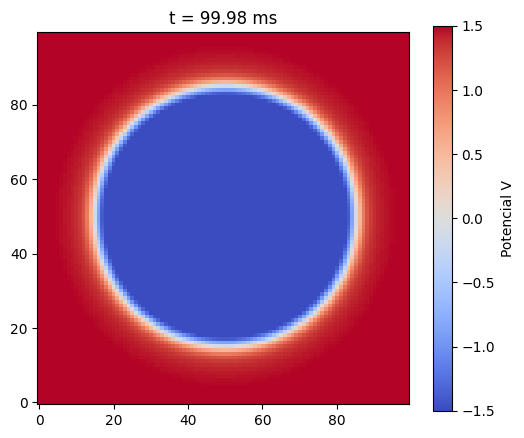

In [ ]:
# ------------------------------------------------------------
# GENERATE ANIMATION
# ------------------------------------------------------------

# Simulation parameters (adjust for a visible wave)
I_amp = 2.5           # Current above the threshold for t_dur=2ms (see your table)
t_dur = 2.0           # ms
Nx, Ny = 100, 100
t_total = 100.0        # total simulation time (ms)
dt = 0.02
frame_interval = 15   # save every 15 steps

# Run the simulation and obtain the frames
frames, times = simulate_and_animate(
    method='explicit',   # can be changed to 'implicit'
    I_amp=I_amp,
    t_dur=t_dur,
    Nx=Nx, Ny=Ny,
    t_total=t_total,
    dt=dt,
    frame_interval=frame_interval
)

# Configure the figure
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(frames[0], cmap='coolwarm', vmin=-1.5, vmax=1.5, origin='lower')
ax.set_title(f't = {times[0]:.2f} ms')
cbar = plt.colorbar(im, ax=ax, label='Potential V')

# Update function for the animation
def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f't = {times[frame_idx]:.2f} ms')
    return im,

# Create the animation
anim = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)

# Display in Colab (HTML5 video)
HTML(anim.to_html5_video())

#anim.save('propagation.gif', writer='pillow', fps=10)

# Appendix A: Tests


TESTE 0D DA DINÂMICA FHN
Iniciando simulação 0D com I_stim=1.0 por 2.0ms


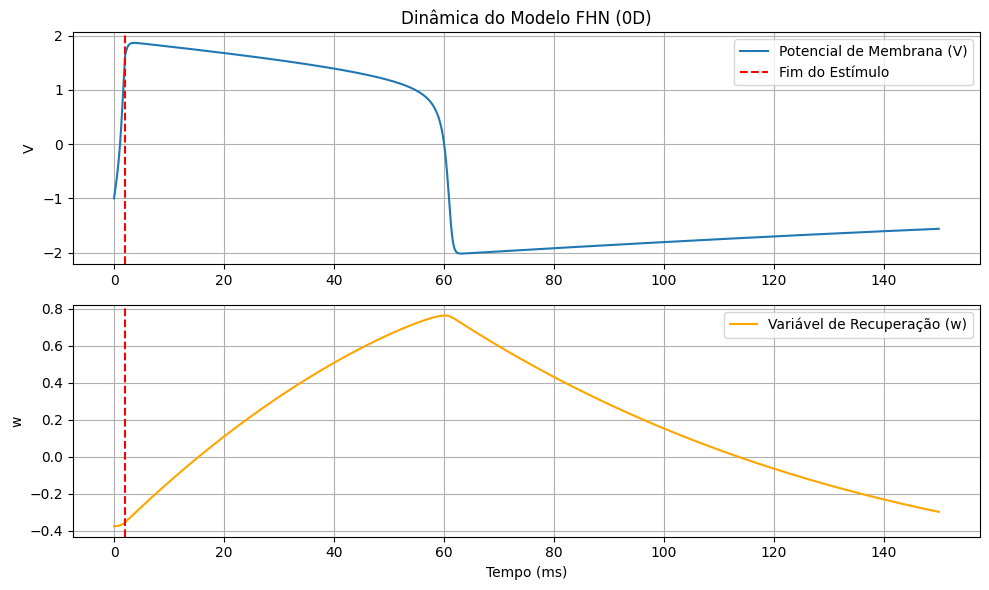

In [ ]:
print('FHN 0D DYNAMICS TEST')

# Simulation parameters for the 0D test
t_total_0D = 150.0 # ms
dt_0D = 0.01 # ms
num_steps_0D = int(t_total_0D / dt_0D)

I_stim_amp_0D = 1.0 # uA/cm²
t_stim_dur_0D = 2.0 # ms

# Initialization (resting values)
V_0D = V_resting
w_0D = w_resting

# Lists to store results for plotting
V_history = [V_0D]
w_history = [w_0D]
t_history = np.linspace(0.0, t_total_0D, num_steps_0D + 1) #Time array

print(f"Starting 0D simulation with I_stim={I_stim_amp_0D} for {t_stim_dur_0D}ms")

# Time loop for the 0D simulation
for step in range(num_steps_0D):
    # current_time represents the time at the end of the current step (t_initial + (step+1)*dt)
    current_time = (step + 1) * dt_0D

    # Apply stimulus
    current_I_stim_0D = I_stim_amp_0D if current_time <= t_stim_dur_0D else 0.0

    # Compute derivatives
    dVdt, dwdt = FHN_derivatives(V_0D, w_0D, current_I_stim_0D)

    # Update V and w using explicit Euler
    V_0D = V_0D + dt_0D * dVdt
    w_0D = w_0D + dt_0D * dwdt

    # Store results
    V_history.append(V_0D)
    w_history.append(w_0D)

# Plot the results
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t_history, V_history, label='Membrane Potential (V)')
plt.title('FHN Model Dynamics (0D)')
plt.ylabel('V')
plt.grid(True)
plt.axvline(x=t_stim_dur_0D, color='r', linestyle='--', label='End of Stimulus')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_history, w_history, label='Recovery Variable (w)', color='orange')
plt.xlabel('Time (ms)')
plt.ylabel('w')
plt.grid(True)
plt.axvline(x=t_stim_dur_0D, color='r', linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

TESTE DA FUNÇÃO aplicar_laplaciano


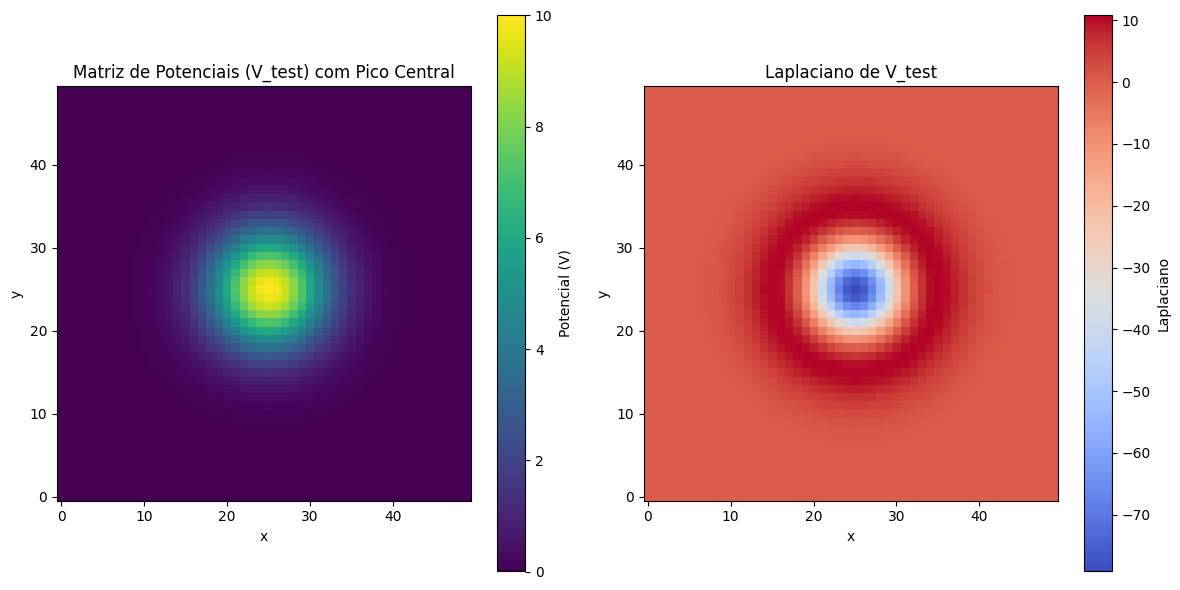

In [ ]:
print('TEST OF THE apply_laplacian FUNCTION')

# Parameters for the test matrix
Nx_test = 50
Ny_test = 50
dx_test = 0.1 # cm

# Create a test matrix with a peak at the center
V_test = np.zeros((Nx_test, Ny_test))

# Center coordinates
center_x, center_y = Nx_test // 2, Ny_test // 2

# Add a Gaussian peak or a single point at the center
peak_amplitude = 10.0
peak_width = 5 # 'peak width'

for i in range(Nx_test):
    for j in range(Ny_test):
        # Distance from the center
        dist_sq = (i - center_x)**2 + (j - center_y)**2
        V_test[i, j] = peak_amplitude * np.exp(-dist_sq / (2 * peak_width**2))

# Apply the Laplacian
lap_V_test = apply_laplacian(V_test, dx_test)

# Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(V_test, cmap='viridis', origin='lower')
plt.title('Potential Matrix (V_test) with Central Peak')
plt.colorbar(label='Potential (V)')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1, 2, 2)
plt.imshow(lap_V_test, cmap='coolwarm', origin='lower') # coolwarm to show positive/negative values
plt.title('Laplacian of V_test')
plt.colorbar(label='Laplaciano')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()